In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_blobs
import warnings
warnings.filterwarnings("ignore")

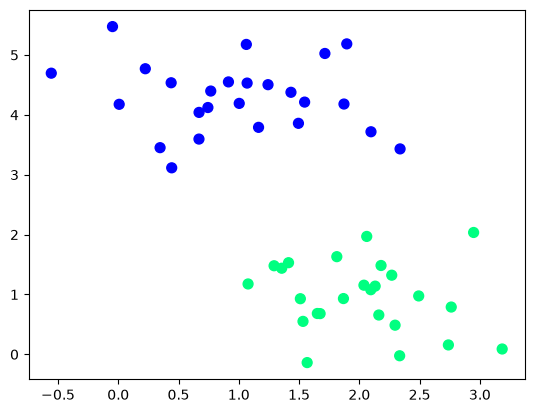

In [4]:
X, y = make_blobs(n_samples=50, centers=2,random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plt.show()

In [10]:
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [11]:
def explain_svm(model, X, y):
    """
    Works only for linear SVC.
    Prints all important SVM quantities and plots them.
    """

    if model.kernel != "linear":
        raise ValueError("This function only works for kernel='linear'")

    # ----------------------------
    # Parameters
    # ----------------------------
    w = model.coef_[0]
    b = model.intercept_[0]

    print("="*60)
    print("SVM PARAMETERS")
    print("="*60)

    print(f"Weight Vector (w): {w}")
    print(f"Bias (b): {b}")

    print("\nHyperplane Equation:")
    print(f"{w[0]:.4f}x1 + {w[1]:.4f}x2 + ({b:.4f}) = 0")

    print("\nπ (Decision Boundary):")
    print(f"{w[0]:.4f}x1 + {w[1]:.4f}x2 + ({b:.4f}) = 0")

    print("\nπ+ :")
    print(f"{w[0]:.4f}x1 + {w[1]:.4f}x2 + ({b:.4f}) = +1")

    print("\nπ- :")
    print(f"{w[0]:.4f}x1 + {w[1]:.4f}x2 + ({b:.4f}) = -1")

    # ----------------------------
    # Margin
    # ----------------------------
    norm_w = np.linalg.norm(w)

    margin = 2 / norm_w
    distance = 1 / norm_w

    print("\n||w|| =", norm_w)

    print(f"\nDistance from Hyperplane to π+ = {distance:.4f}")
    print(f"Distance from Hyperplane to π- = {distance:.4f}")
    print(f"Total Margin Width = {margin:.4f}")

    # ----------------------------
    # Support Vectors
    # ----------------------------
    print("\nSupport Vectors\n")

    for i, sv in enumerate(model.support_vectors_):
        print(f"SV {i+1}: {sv}")

    print("\nIndices of Support Vectors:")
    print(model.support_)

    print("\nNumber of Support Vectors in each class:")
    print(model.n_support_)

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------

    fig, ax = plt.subplots(figsize=(8,6))

    # Data
    ax.scatter(X[:,0], X[:,1],
               c=y,
               cmap='bwr',
               s=60)

    # Limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0]-1, xlim[1]+1, 200)

    # Hyperplane
    yy = -(w[0]*xx + b)/w[1]

    # π+
    yy_up = -(w[0]*xx + b - 1)/w[1]

    # π-
    yy_down = -(w[0]*xx + b + 1)/w[1]

    # Plot Lines
    ax.plot(xx, yy,
            'k',
            linewidth=2,
            label='π (Decision Boundary)')

    ax.plot(xx, yy_up,
            'k--',
            linewidth=2,
            label='π+')

    ax.plot(xx, yy_down,
            'k--',
            linewidth=2,
            label='π-')

    # Support vectors
    ax.scatter(model.support_vectors_[:,0],
               model.support_vectors_[:,1],
               s=250,
               facecolors='none',
               edgecolors='green',
               linewidth=2,
               label='Support Vectors')

    # Annotate support vectors
    for i, sv in enumerate(model.support_vectors_):
        ax.text(sv[0], sv[1]+0.15,
                f"SV{i+1}",
                fontsize=10,
                color="green")

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

    ax.set_title("SVM Hyperplane, Margins and Support Vectors")

    ax.legend()

    plt.show()

SVM PARAMETERS
Weight Vector (w): [ 0.22967329 -1.37758262]
Bias (b): 3.189713537020001

Hyperplane Equation:
0.2297x1 + -1.3776x2 + (3.1897) = 0

π (Decision Boundary):
0.2297x1 + -1.3776x2 + (3.1897) = 0

π+ :
0.2297x1 + -1.3776x2 + (3.1897) = +1

π- :
0.2297x1 + -1.3776x2 + (3.1897) = -1

||w|| = 1.3965971889989595

Distance from Hyperplane to π+ = 0.7160
Distance from Hyperplane to π- = 0.7160
Total Margin Width = 1.4321

Support Vectors

SV 1: [0.44359863 3.11530945]
SV 2: [2.33812285 3.43116792]
SV 3: [2.06156753 1.96918596]

Indices of Support Vectors:
[18 25  7]

Number of Support Vectors in each class:
[2 1]


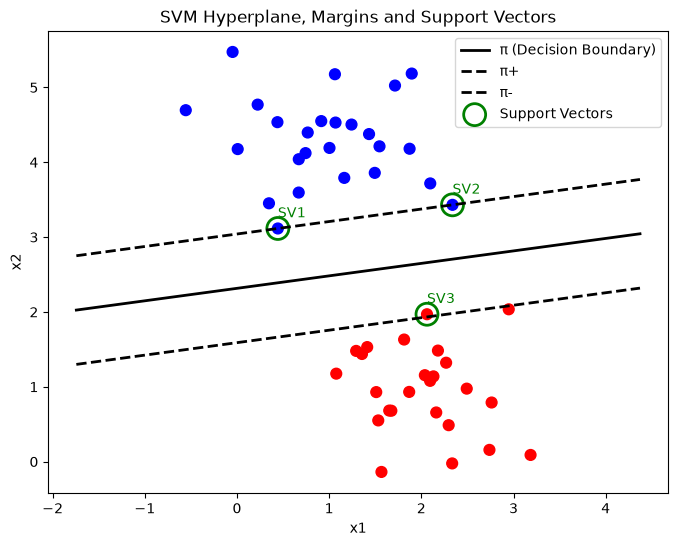

In [12]:
explain_svm(svm_classifier, X, y)